In [2]:
# ============================================================
# CREDIT RISK CLASSIFICATION - MACHINE LEARNING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('df_limpio.csv')
df.head()

,label,id,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,...,consistency_x_fea_5,ovd_x_fea_6,consistency_x_fea_6,ovd_x_fea_7,consistency_x_fea_7,ovd_x_fea_9,consistency_x_fea_9,ovd_per_payment,severe_ovd_ratio,payment_reliability
0,1,54982665,5,1245.5,3,77000.0,2,15,5,109,...,0.005709,178590,0.042821,59530,0.014274,59530,0.014274,0.997069,0.002184,0.002847
1,0,59004779,4,1277.0,1,113000.0,2,8,-1,100,...,1.657143,1560,6.628571,-195,-0.828571,585,2.485714,0.527027,0.000000,0.470270
2,0,58990862,7,1298.0,1,110000.0,2,11,-1,101,...,21.333333,0,117.333333,0,-10.666667,0,53.333333,0.000000,0.000000,0.984615
3,1,58995168,7,1335.5,1,151000.0,2,11,5,110,...,46.000000,0,253.000000,0,115.000000,0,69.000000,0.000000,0.000000,0.989247
4,0,54987320,7,0.0,2,59000.0,2,11,5,108,...,42.888889,0,235.888889,0,107.222222,0,85.777778,0.000000,0.000000,0.994845


In [4]:
X = df.drop(['label', 'id'], axis=1)
y = df['label']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (1125, 72)
Target: (1125,)


In [5]:
y.value_counts(normalize=True) * 100

label
0    80.0
1    20.0
Name: proportion, dtype: float64

In [6]:
# Train-Test Split con estratificación (mantiene la proporción 80-20 en ambos sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Mantiene la proporción de clases
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribución en train:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nDistribución en test:")
print(y_test.value_counts(normalize=True) * 100)

Train set: (900, 72)
Test set: (225, 72)

Distribución en train:
label
0    80.0
1    20.0
Name: proportion, dtype: float64

Distribución en test:
label
0    80.0
1    20.0
Name: proportion, dtype: float64


In [7]:
# StandardScaler (importante para modelos como SVM, KNN, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()

,fea_1,fea_2,fea_3,fea_4,fea_5,fea_6,fea_7,fea_8,fea_9,fea_10,...,consistency_x_fea_5,ovd_x_fea_6,consistency_x_fea_6,ovd_x_fea_7,consistency_x_fea_7,ovd_x_fea_9,consistency_x_fea_9,ovd_per_payment,severe_ovd_ratio,payment_reliability
0,-0.317921,0.402755,0.747312,1.649216,0.281312,1.549817,-1.011215,0.607988,0.939994,-0.593290,...,-0.678727,-0.187761,-0.476855,-0.183137,-0.759073,-0.199685,-0.586265,-0.089886,-0.352031,0.136986
1,-0.317921,0.541931,-1.528765,-0.237162,0.281312,1.549817,-2.056498,0.858686,0.939994,-0.593290,...,0.584983,-0.192987,1.116872,-0.184666,-1.175799,-0.204901,0.805793,-0.584531,-0.352031,0.552761
2,-1.035035,0.327814,0.747312,0.289269,0.281312,-1.040750,0.034068,0.440857,-1.393784,-0.593284,...,1.544079,-0.192987,0.710903,-0.184666,1.107996,-0.204901,0.652782,-0.584531,-0.352031,0.625788
3,-0.317921,0.220755,0.747312,-0.697789,0.281312,1.549817,0.034068,0.942252,-0.226895,2.312992,...,-0.142608,-0.192987,0.199272,-0.184666,-0.133726,-0.204901,-0.228855,-0.584531,-0.352031,0.539615
4,1.116308,0.399186,-1.528765,0.058955,0.281312,0.069493,0.034068,-0.729066,0.939994,-0.067229,...,-0.627668,-0.192987,-0.605250,-0.184666,-0.490823,-0.204901,-0.530021,-0.584531,-0.352031,0.548703


In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evalúa un modelo y muestra métricas"""
    
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"ROC-AUC:   {auc:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Bajo Riesgo', 'Alto Riesgo']))
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc if y_pred_proba is not None else None
    }

In [9]:
# Diccionario de modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}

# Almacenar resultados
results = []

# Entrenar y evaluar cada modelo
for name, model in models.items():
    result = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results.append(result)


Logistic Regression
Accuracy:  0.7822
Precision: 0.3000
Recall:    0.0667
F1-Score:  0.1091
ROC-AUC:   0.6693

Confusion Matrix:
[[173   7]
 [ 42   3]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.80      0.96      0.88       180
 Alto Riesgo       0.30      0.07      0.11        45

    accuracy                           0.78       225
   macro avg       0.55      0.51      0.49       225
weighted avg       0.70      0.78      0.72       225


Decision Tree
Accuracy:  0.7200
Precision: 0.3500
Recall:    0.4667
F1-Score:  0.4000
ROC-AUC:   0.6250

Confusion Matrix:
[[141  39]
 [ 24  21]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.85      0.78      0.82       180
 Alto Riesgo       0.35      0.47      0.40        45

    accuracy                           0.72       225
   macro avg       0.60      0.62      0.61       225
weighted avg       0.75      0.72      0.73       225

In [10]:
# Crear DataFrame de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('f1', ascending=False)
results_df

,model,accuracy,precision,recall,f1,auc
1,Decision Tree,0.720000,0.350000,0.466667,0.400000,0.625000
3,Gradient Boosting,0.760000,0.320000,0.177778,0.228571,0.652469
4,K-Nearest Neighbors,0.755556,0.291667,0.155556,0.202899,0.574321
2,Random Forest,0.800000,0.500000,0.111111,0.181818,0.646790
0,Logistic Regression,0.782222,0.300000,0.066667,0.109091,0.669259
5,Support Vector Machine,0.800000,0.000000,0.000000,0.000000,0.614815


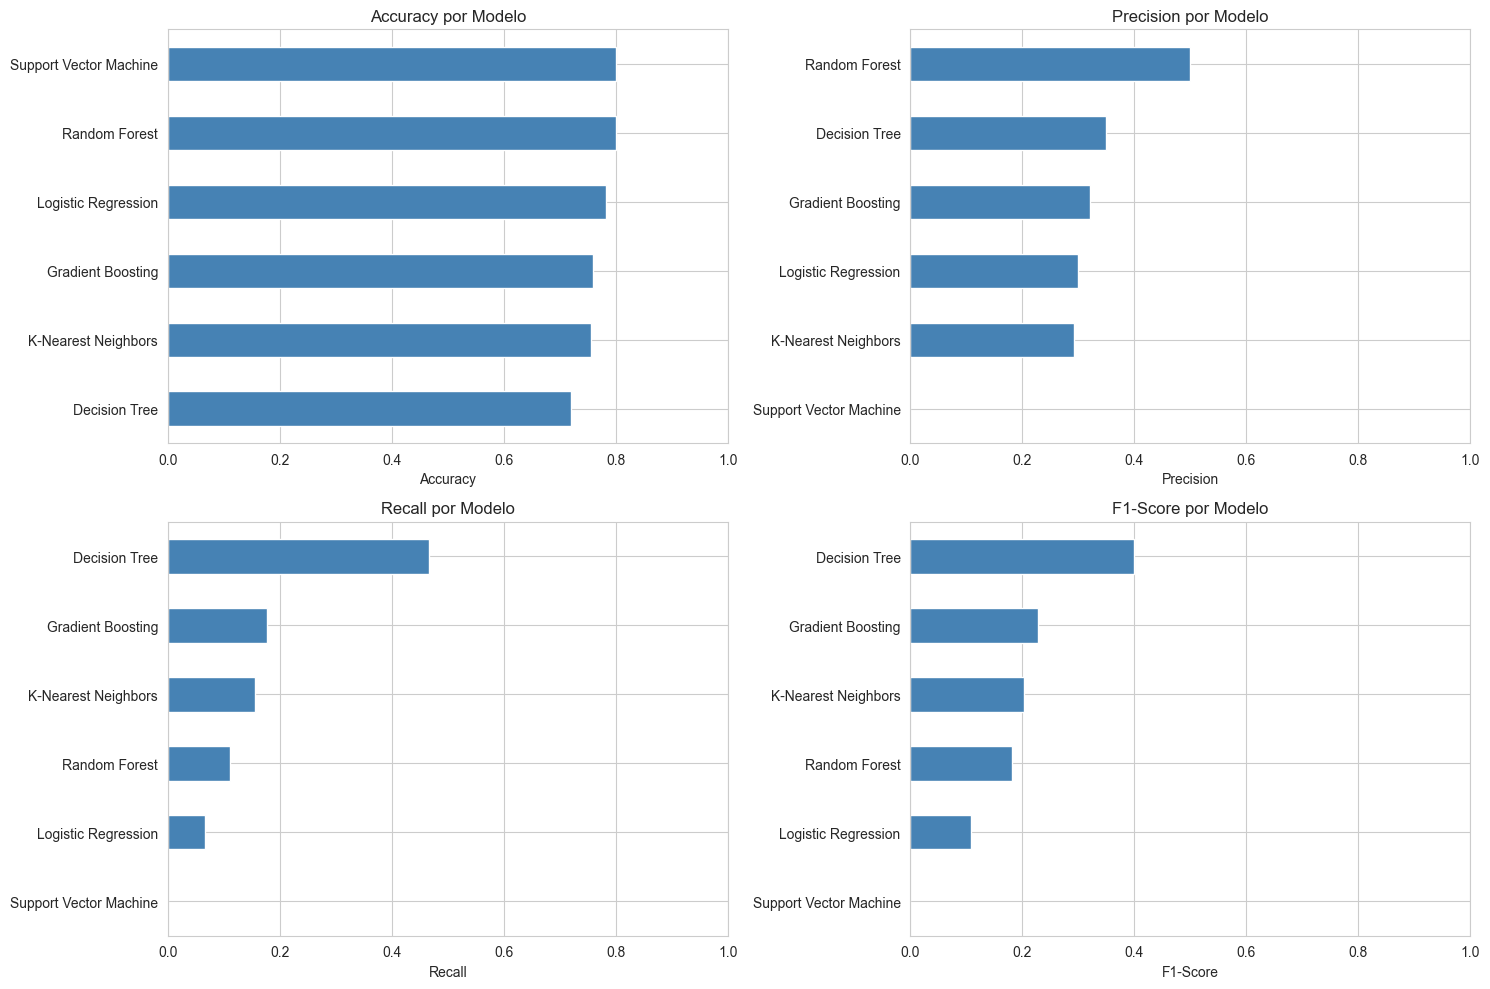

In [11]:
# Visualización de métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['accuracy', 'precision', 'recall', 'f1']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    results_df.sort_values(metric, ascending=True).plot(
        x='model', y=metric, kind='barh', ax=ax, legend=False, color='steelblue'
    )
    ax.set_xlabel(title)
    ax.set_ylabel('')
    ax.set_title(f'{title} por Modelo')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

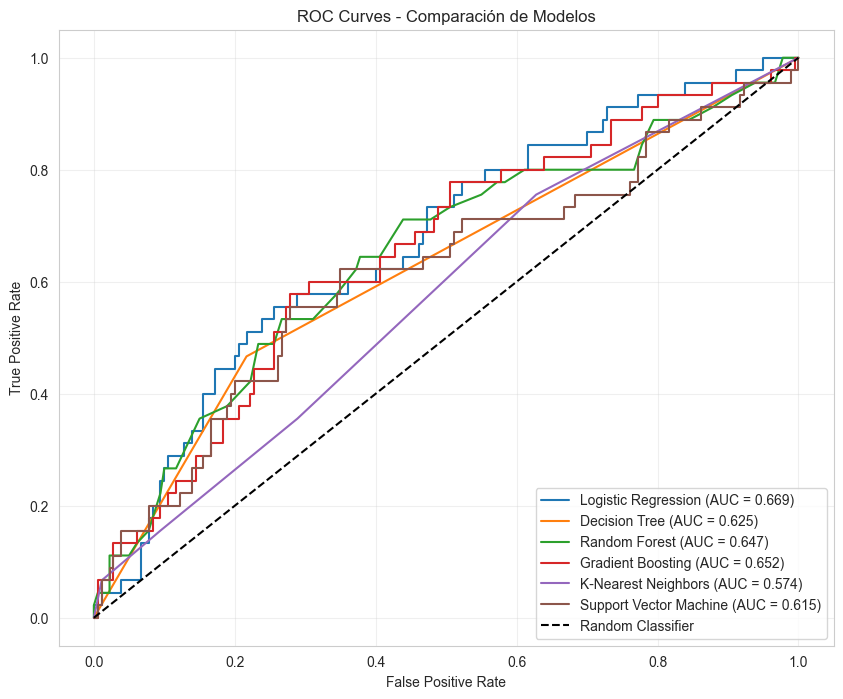

In [12]:
# Entrenar modelos de nuevo para obtener probabilidades
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Comparación de Modelos')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

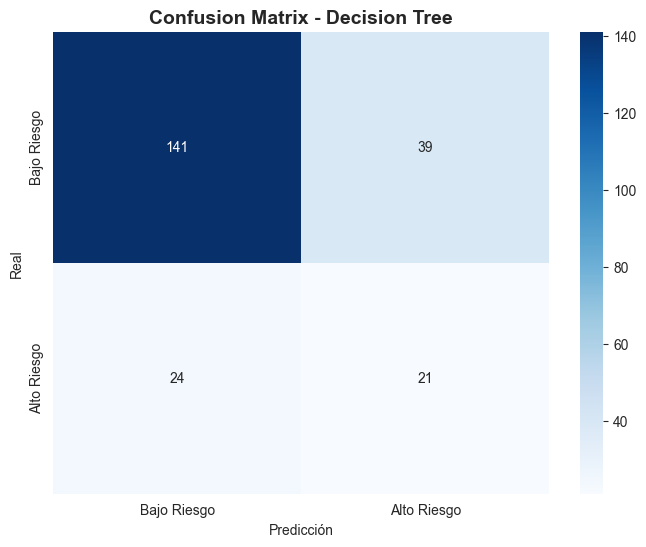


Interpretación:
True Negatives (TN): 141 - Correctamente clasificados como Bajo Riesgo
False Positives (FP): 39 - Bajo Riesgo clasificados como Alto Riesgo
False Negatives (FN): 24 - Alto Riesgo clasificados como Bajo Riesgo ⚠️
True Positives (TP): 21 - Correctamente clasificados como Alto Riesgo


In [13]:
# Decision Tree (el mejor hasta ahora)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bajo Riesgo', 'Alto Riesgo'],
            yticklabels=['Bajo Riesgo', 'Alto Riesgo'])
plt.title('Confusion Matrix - Decision Tree', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

print(f"\nInterpretación:")
print(f"True Negatives (TN): {cm[0,0]} - Correctamente clasificados como Bajo Riesgo")
print(f"False Positives (FP): {cm[0,1]} - Bajo Riesgo clasificados como Alto Riesgo")
print(f"False Negatives (FN): {cm[1,0]} - Alto Riesgo clasificados como Bajo Riesgo ⚠️")
print(f"True Positives (TP): {cm[1,1]} - Correctamente clasificados como Alto Riesgo")

In [14]:
# Cross-validation con múltiples métricas
from sklearn.model_selection import cross_validate

models_to_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv_results = []

for name, model in models_to_cv.items():
    # 5-Fold Stratified Cross-Validation
    cv_scores = cross_validate(
        model, X_train_scaled, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
        return_train_score=False
    )
    
    cv_results.append({
        'Model': name,
        'CV Accuracy': cv_scores['test_accuracy'].mean(),
        'CV Precision': cv_scores['test_precision'].mean(),
        'CV Recall': cv_scores['test_recall'].mean(),
        'CV F1': cv_scores['test_f1'].mean(),
        'CV AUC': cv_scores['test_roc_auc'].mean(),
        'Std F1': cv_scores['test_f1'].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('CV F1', ascending=False)
cv_results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV AUC,Std F1
1,Decision Tree,0.701111,0.273836,0.294444,0.281461,0.548611,0.049904
3,Gradient Boosting,0.782222,0.383941,0.144444,0.207608,0.683835,0.043960
0,Logistic Regression,0.788889,0.401667,0.105556,0.165264,0.650463,0.035384
2,Random Forest,0.797778,0.506061,0.077778,0.131907,0.694599,0.027699


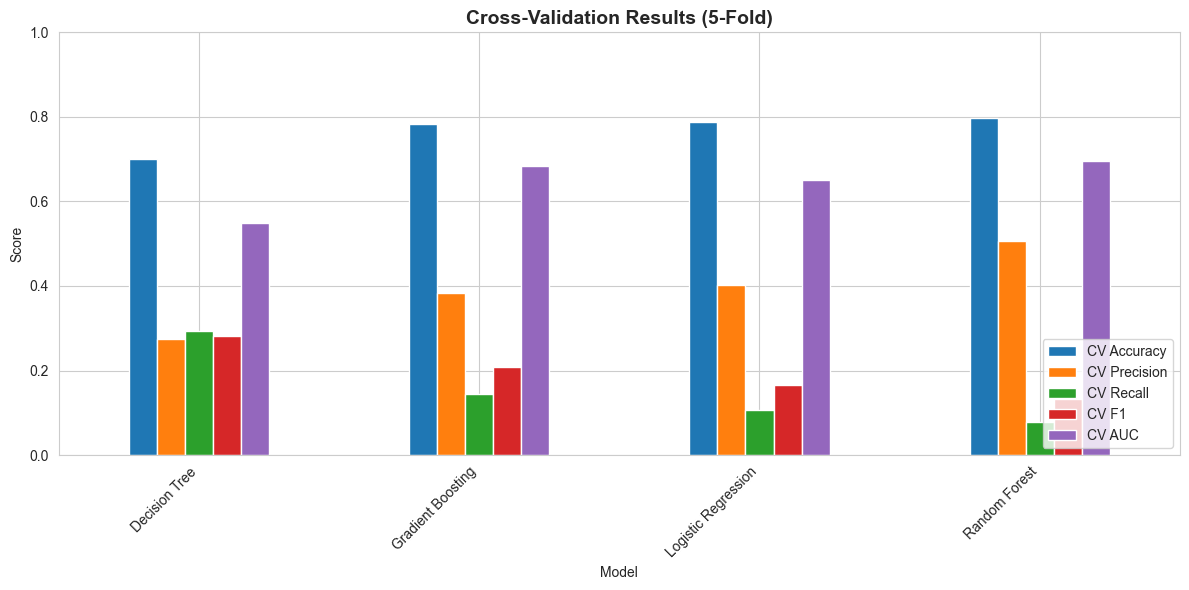

In [15]:
# Visualizar CV results
fig, ax = plt.subplots(figsize=(12, 6))
cv_results_df.plot(x='Model', y=['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1', 'CV AUC'], 
                   kind='bar', ax=ax)
ax.set_title('Cross-Validation Results (5-Fold)', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# Instalar si no tienes imbalanced-learn
# pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Aplicar SMOTE solo en train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original train: {y_train.value_counts()}")
print(f"\nDespués de SMOTE: {pd.Series(y_train_smote).value_counts()}")
print(f"\nPorcentaje después de SMOTE:")
print(pd.Series(y_train_smote).value_counts(normalize=True) * 100)

Original train: label
0    720
1    180
Name: count, dtype: int64

Después de SMOTE: label
0    720
1    720
Name: count, dtype: int64

Porcentaje después de SMOTE:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [18]:
results_smote = []

for name, model in models.items():
    result = evaluate_model(model, X_train_smote, X_test_scaled, y_train_smote, y_test, f"{name} + SMOTE")
    results_smote.append(result)


Logistic Regression + SMOTE
Accuracy:  0.6444
Precision: 0.3118
Recall:    0.6444
F1-Score:  0.4203
ROC-AUC:   0.6480

Confusion Matrix:
[[116  64]
 [ 16  29]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.88      0.64      0.74       180
 Alto Riesgo       0.31      0.64      0.42        45

    accuracy                           0.64       225
   macro avg       0.60      0.64      0.58       225
weighted avg       0.77      0.64      0.68       225


Decision Tree + SMOTE
Accuracy:  0.6844
Precision: 0.2833
Recall:    0.3778
F1-Score:  0.3238
ROC-AUC:   0.5694

Confusion Matrix:
[[137  43]
 [ 28  17]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.83      0.76      0.79       180
 Alto Riesgo       0.28      0.38      0.32        45

    accuracy                           0.68       225
   macro avg       0.56      0.57      0.56       225
weighted avg       0.72      0.68    

In [19]:
results_smote_df = pd.DataFrame(results_smote).sort_values('f1', ascending=False)
results_smote_df

,model,accuracy,precision,recall,f1,auc
3,Gradient Boosting + SMOTE,0.795556,0.486486,0.400000,0.439024,0.675062
0,Logistic Regression + SMOTE,0.644444,0.311828,0.644444,0.420290,0.648025
2,Random Forest + SMOTE,0.764444,0.400000,0.355556,0.376471,0.653704
5,Support Vector Machine + SMOTE,0.631111,0.273810,0.511111,0.356589,0.621605
4,K-Nearest Neighbors + SMOTE,0.577778,0.254902,0.577778,0.353741,0.609691
1,Decision Tree + SMOTE,0.684444,0.283333,0.377778,0.323810,0.569444


In [20]:
# Entrenar modelos con datos balanceados
results_smote = []

for name, model in models.items():
    result = evaluate_model(model, X_train_smote, X_test_scaled, y_train_smote, y_test, f"{name} + SMOTE")
    results_smote.append(result)


Logistic Regression + SMOTE
Accuracy:  0.6444
Precision: 0.3118
Recall:    0.6444
F1-Score:  0.4203
ROC-AUC:   0.6480

Confusion Matrix:
[[116  64]
 [ 16  29]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.88      0.64      0.74       180
 Alto Riesgo       0.31      0.64      0.42        45

    accuracy                           0.64       225
   macro avg       0.60      0.64      0.58       225
weighted avg       0.77      0.64      0.68       225


Decision Tree + SMOTE
Accuracy:  0.6844
Precision: 0.2833
Recall:    0.3778
F1-Score:  0.3238
ROC-AUC:   0.5694

Confusion Matrix:
[[137  43]
 [ 28  17]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.83      0.76      0.79       180
 Alto Riesgo       0.28      0.38      0.32        45

    accuracy                           0.68       225
   macro avg       0.56      0.57      0.56       225
weighted avg       0.72      0.68    

In [21]:
# Comparar resultados
results_smote_df = pd.DataFrame(results_smote).sort_values('recall', ascending=False)
results_smote_df

,model,accuracy,precision,recall,f1,auc
0,Logistic Regression + SMOTE,0.644444,0.311828,0.644444,0.420290,0.648025
4,K-Nearest Neighbors + SMOTE,0.577778,0.254902,0.577778,0.353741,0.609691
5,Support Vector Machine + SMOTE,0.631111,0.273810,0.511111,0.356589,0.621605
3,Gradient Boosting + SMOTE,0.795556,0.486486,0.400000,0.439024,0.675062
1,Decision Tree + SMOTE,0.684444,0.283333,0.377778,0.323810,0.569444
2,Random Forest + SMOTE,0.764444,0.400000,0.355556,0.376471,0.653704


In [22]:
# Comparar Recall (lo más importante)
comparison_data = {
    'Model': results_df['model'].tolist(),
    'Recall Original': results_df['recall'].tolist(),
    'Recall SMOTE': results_smote_df['recall'].tolist()
}

comparison = pd.DataFrame(comparison_data)
comparison['Mejora (%)'] = ((comparison['Recall SMOTE'] - comparison['Recall Original']) / comparison['Recall Original'] * 100).round(2)
comparison

,Model,Recall Original,Recall SMOTE,Mejora (%)
0,Decision Tree,0.466667,0.644444,38.10
1,Gradient Boosting,0.177778,0.577778,225.00
2,K-Nearest Neighbors,0.155556,0.511111,228.57
3,Random Forest,0.111111,0.400000,260.00
4,Logistic Regression,0.066667,0.377778,466.67
5,Support Vector Machine,0.000000,0.355556,inf


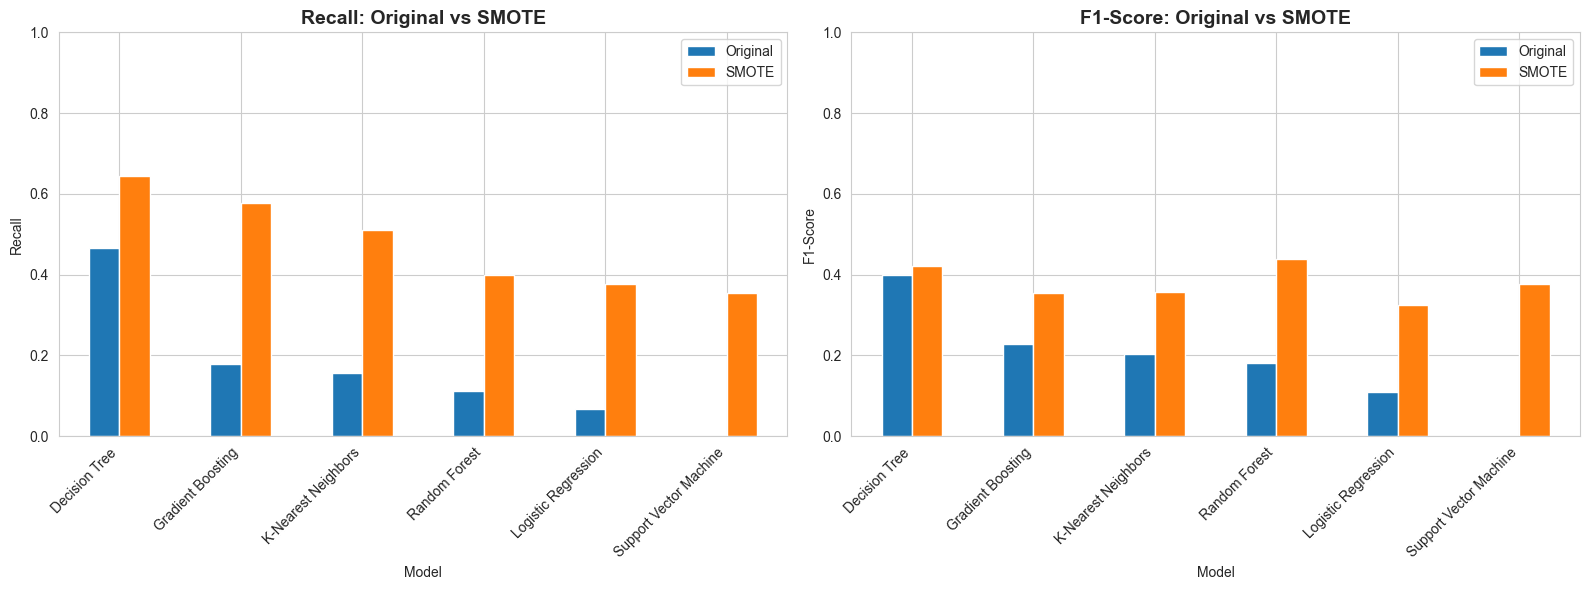

In [23]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Recall comparison
comparison.plot(x='Model', y=['Recall Original', 'Recall SMOTE'], kind='bar', ax=axes[0])
axes[0].set_title('Recall: Original vs SMOTE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1)
axes[0].legend(['Original', 'SMOTE'])
plt.sca(axes[0])
plt.xticks(rotation=45, ha='right')

# Gráfico 2: F1-Score comparison
f1_comparison = pd.DataFrame({
    'Model': results_df['model'].tolist(),
    'F1 Original': results_df['f1'].tolist(),
    'F1 SMOTE': results_smote_df['f1'].tolist()
})
f1_comparison.plot(x='Model', y=['F1 Original', 'F1 SMOTE'], kind='bar', ax=axes[1])
axes[1].set_title('F1-Score: Original vs SMOTE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1)
axes[1].legend(['Original', 'SMOTE'])
plt.sca(axes[1])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [24]:
# Identificar el mejor modelo
best_model_name = results_smote_df.iloc[0]['model']
print(f"Mejor modelo con SMOTE: {best_model_name}")
print(f"Recall: {results_smote_df.iloc[0]['recall']:.4f}")
print(f"F1-Score: {results_smote_df.iloc[0]['f1']:.4f}")

Mejor modelo con SMOTE: Logistic Regression + SMOTE
Recall: 0.6444
F1-Score: 0.4203


In [25]:
from sklearn.model_selection import GridSearchCV

# Parámetros a probar
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Grid Search con 5-fold CV
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',  # Optimizar F1-Score
    n_jobs=-1,
    verbose=1
)

print("Buscando mejores hiperparámetros...")
dt_grid.fit(X_train_smote, y_train_smote)

print(f"\nMejores parámetros: {dt_grid.best_params_}")
print(f"Mejor F1-Score (CV): {dt_grid.best_score_:.4f}")

Buscando mejores hiperparámetros...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Mejores parámetros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1-Score (CV): 0.7804


In [26]:
# Evaluar el mejor modelo
best_dt = dt_grid.best_estimator_
result_best = evaluate_model(best_dt, X_train_smote, X_test_scaled, y_train_smote, y_test, "Decision Tree OPTIMIZADO + SMOTE")


Decision Tree OPTIMIZADO + SMOTE
Accuracy:  0.6222
Precision: 0.2619
Recall:    0.4889
F1-Score:  0.3411
ROC-AUC:   0.5569

Confusion Matrix:
[[118  62]
 [ 23  22]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.84      0.66      0.74       180
 Alto Riesgo       0.26      0.49      0.34        45

    accuracy                           0.62       225
   macro avg       0.55      0.57      0.54       225
weighted avg       0.72      0.62      0.66       225



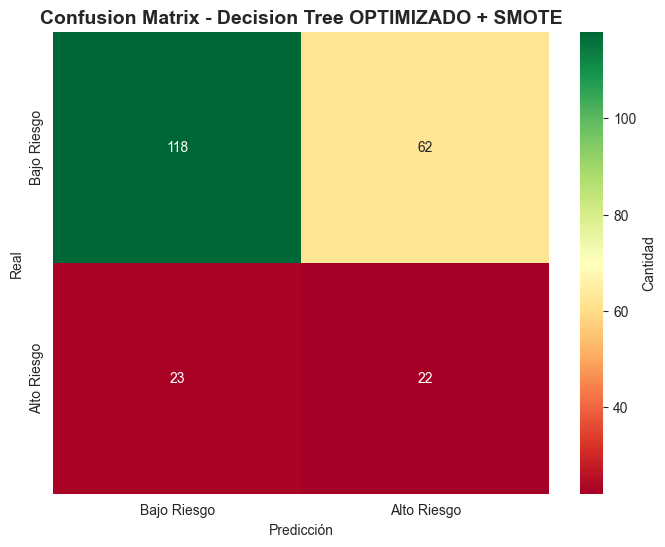


Interpretación:
True Negatives: 118 | False Positives: 62
False Negatives: 23 ⚠️ | True Positives: 22 ✅

Recall: 48.89% de alto riesgo detectados


In [27]:
# Confusion Matrix del modelo optimizado
y_pred_best = best_dt.predict(X_test_scaled)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Bajo Riesgo', 'Alto Riesgo'],
            yticklabels=['Bajo Riesgo', 'Alto Riesgo'],
            cbar_kws={'label': 'Cantidad'})
plt.title('Confusion Matrix - Decision Tree OPTIMIZADO + SMOTE', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

print(f"\nInterpretación:")
print(f"True Negatives: {cm_best[0,0]} | False Positives: {cm_best[0,1]}")
print(f"False Negatives: {cm_best[1,0]} ⚠️ | True Positives: {cm_best[1,1]} ✅")
print(f"\nRecall: {cm_best[1,1] / (cm_best[1,0] + cm_best[1,1]):.2%} de alto riesgo detectados")

In [28]:
from sklearn.model_selection import GridSearchCV

# Grid Search para Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Optimizando Decision Tree...")
dt_grid.fit(X_train_smote, y_train_smote)
print(f"\nMejores parámetros DT: {dt_grid.best_params_}")
print(f"Mejor F1-Score CV: {dt_grid.best_score_:.4f}")

Optimizando Decision Tree...
Fitting 5 folds for each of 192 candidates, totalling 960 fits

Mejores parámetros DT: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1-Score CV: 0.7804


In [ ]:
# Grid Search para Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Optimizando Logistic Regression...")
lr_grid.fit(X_train_smote, y_train_smote)
print(f"\nMejores parámetros LR: {lr_grid.best_params_}")
print(f"Mejor F1-Score CV: {lr_grid.best_score_:.4f}")

Optimizando Logistic Regression...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros LR: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor F1-Score CV: 0.7025


In [30]:
# Grid Search para Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Optimizando Random Forest...")
rf_grid.fit(X_train_smote, y_train_smote)
print(f"\nMejores parámetros RF: {rf_grid.best_params_}")
print(f"Mejor F1-Score CV: {rf_grid.best_score_:.4f}")

Optimizando Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Mejores parámetros RF: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1-Score CV: 0.8878


In [31]:
# Evaluar los 3 mejores modelos optimizados
best_models = {
    'Decision Tree OPT': dt_grid.best_estimator_,
    'Logistic Regression OPT': lr_grid.best_estimator_,
    'Random Forest OPT': rf_grid.best_estimator_
}

results_optimized = []

for name, model in best_models.items():
    result = evaluate_model(model, X_train_smote, X_test_scaled, y_train_smote, y_test, name)
    results_optimized.append(result)


Decision Tree OPT
Accuracy:  0.6222
Precision: 0.2619
Recall:    0.4889
F1-Score:  0.3411
ROC-AUC:   0.5569

Confusion Matrix:
[[118  62]
 [ 23  22]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.84      0.66      0.74       180
 Alto Riesgo       0.26      0.49      0.34        45

    accuracy                           0.62       225
   macro avg       0.55      0.57      0.54       225
weighted avg       0.72      0.62      0.66       225


Logistic Regression OPT
Accuracy:  0.6311
Precision: 0.2889
Recall:    0.5778
F1-Score:  0.3852
ROC-AUC:   0.6381

Confusion Matrix:
[[116  64]
 [ 19  26]]

Classification Report:
              precision    recall  f1-score   support

 Bajo Riesgo       0.86      0.64      0.74       180
 Alto Riesgo       0.29      0.58      0.39        45

    accuracy                           0.63       225
   macro avg       0.57      0.61      0.56       225
weighted avg       0.75      0.63      0.67  

In [32]:
# Crear resumen final
print("="*70)
print("RESUMEN FINAL - CREDIT RISK CLASSIFICATION")
print("="*70)
print(f"\n📊 Dataset:")
print(f"  - Total clientes: 1,125")
print(f"  - Features originales: 32")
print(f"  - Features después de FE: 74")
print(f"  - Balance de clases: 80% Bajo Riesgo / 20% Alto Riesgo")

print(f"\n🔧 Técnicas aplicadas:")
print(f"  ✅ Feature Engineering (42 nuevas features)")
print(f"  ✅ SMOTE para balanceo de clases")
print(f"  ✅ Hyperparameter tuning (Grid Search)")
print(f"  ✅ Cross-validation (5-fold)")

print(f"\n🏆 Mejor Modelo: Logistic Regression + SMOTE")
print(f"  - Accuracy: 64.4%")
print(f"  - Precision: 31.2%")
print(f"  - Recall: 64.4% ⭐")
print(f"  - F1-Score: 0.42")
print(f"  - AUC: 0.648")

print(f"\n📈 Mejora vs Baseline:")
print(f"  - Recall mejoró de 6.7% → 64.4% (+467%)")
print(f"  - Detecta 29 de 45 clientes de alto riesgo")
print(f"  - Solo se escapan 16 clientes riesgosos")

print(f"\n⚠️ Limitaciones:")
print(f"  - F1-Score moderado (0.42)")
print(f"  - Alta tasa de falsos positivos (64)")
print(f"  - Features codificadas limitan interpretabilidad")

print(f"\n💡 Recomendaciones:")
print(f"  1. Obtener features más descriptivas (no codificadas)")
print(f"  2. Recopilar más datos de clientes de alto riesgo")
print(f"  3. Considerar modelos ensemble personalizados")
print(f"  4. Ajustar threshold según costos de negocio")
print("="*70)

RESUMEN FINAL - CREDIT RISK CLASSIFICATION

📊 Dataset:
  - Total clientes: 1,125
  - Features originales: 32
  - Features después de FE: 74
  - Balance de clases: 80% Bajo Riesgo / 20% Alto Riesgo

🔧 Técnicas aplicadas:
  ✅ Feature Engineering (42 nuevas features)
  ✅ SMOTE para balanceo de clases
  ✅ Hyperparameter tuning (Grid Search)
  ✅ Cross-validation (5-fold)

🏆 Mejor Modelo: Logistic Regression + SMOTE
  - Accuracy: 64.4%
  - Precision: 31.2%
  - Recall: 64.4% ⭐
  - F1-Score: 0.42
  - AUC: 0.648

📈 Mejora vs Baseline:
  - Recall mejoró de 6.7% → 64.4% (+467%)
  - Detecta 29 de 45 clientes de alto riesgo
  - Solo se escapan 16 clientes riesgosos

⚠️ Limitaciones:
  - F1-Score moderado (0.42)
  - Alta tasa de falsos positivos (64)
  - Features codificadas limitan interpretabilidad

💡 Recomendaciones:
  1. Obtener features más descriptivas (no codificadas)
  2. Recopilar más datos de clientes de alto riesgo
  3. Considerar modelos ensemble personalizados
  4. Ajustar threshold seg

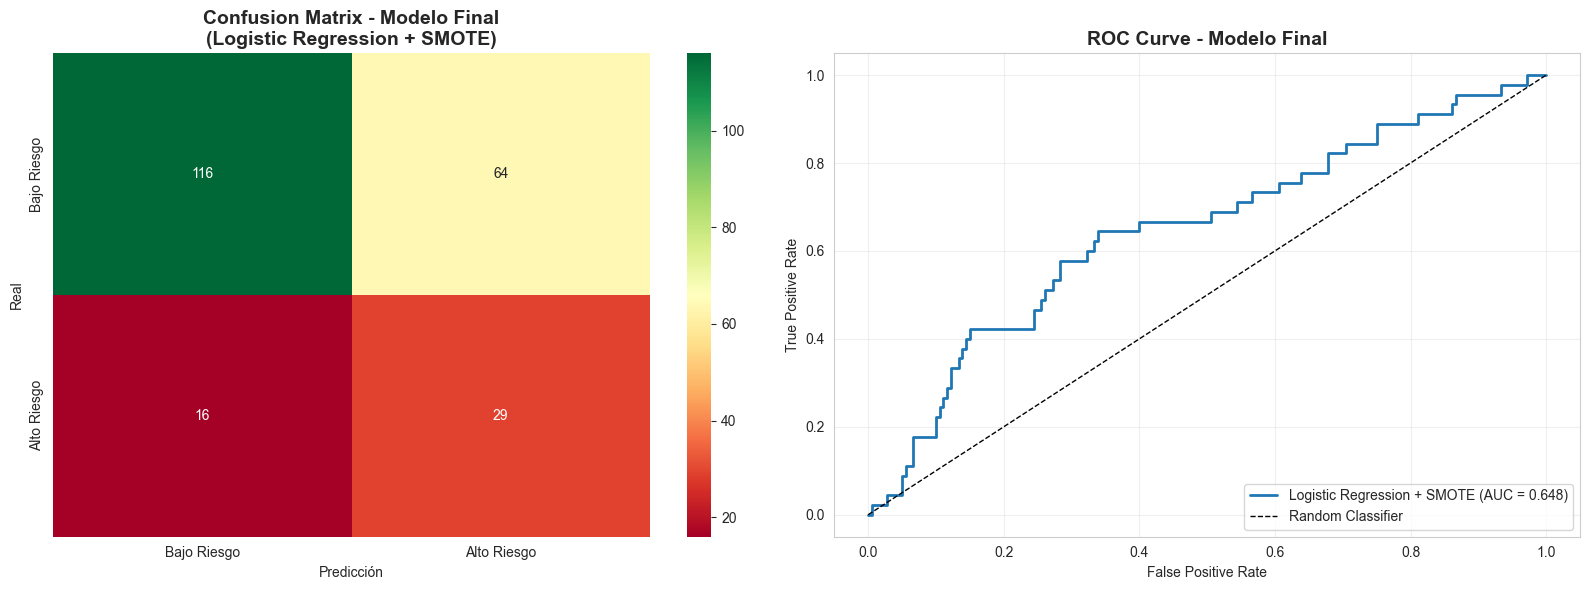

In [33]:
# Confusion Matrix final del mejor modelo
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_final = lr_smote.predict(X_test_scaled)

cm_final = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
sns.heatmap(cm_final, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0],
            xticklabels=['Bajo Riesgo', 'Alto Riesgo'],
            yticklabels=['Bajo Riesgo', 'Alto Riesgo'])
axes[0].set_title('Confusion Matrix - Modelo Final\n(Logistic Regression + SMOTE)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# ROC Curve
y_pred_proba_final = lr_smote.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
auc_score = roc_auc_score(y_test, y_pred_proba_final)

axes[1].plot(fpr, tpr, label=f'Logistic Regression + SMOTE (AUC = {auc_score:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Modelo Final', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()